# Iterative Radiomics-Guided Region Growing Algorithm



## Objective

Implement an iterative region growing algorithm using voxel-based PyRadiomics features on PEtCT tumor images.

## Algorithm Overview

1. **Load PEtCT DICOM Study**: Import full 3D DICOM series using SimpleITK
2. **Extract & Display Coronal Slice**: Select a specific coronal plane for analysis
3. **Define Working ROI**: Crop the coronal slice to the region of interest
4. **Create Initial Lesion Mask**: Apply intensity thresholding to identify potential lesion
5. **Compute Reference Radiomic Map**: Extract voxel-based Median map inside initial ROI (ROI0)
6. **Establish Statistical Limits**: Use ROI0 distribution as fixed reference (mean ± k*std)
7. **Iterative Region Growing**:
   - Dilate current ROI to generate candidate voxels (corona)
   - Compute voxel-based Median for dilated region
   - Classify each voxel: accept if within statistical bounds
   - Update ROI with accepted voxels
   - Repeat for N iterations
8. **Generate Results & Visualizations**

## Key Implementation Details

- **Radiomic Feature**: `firstorder.Median` (voxel-based)
- **Reference Distribution**: Fixed throughout all iterations
- **PyRadiomics Coordinate Handling**: Automatic reconstruction from bounding-box to full-image coordinates
- **Configurable Parameters**: Threshold percentage, k-value, number of iterations

In [91]:
# ============================================================================== 
# 1. IMPORTS & SETUP
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patches as patches
import SimpleITK as sitk
from pathlib import Path
from radiomics.glcm import RadiomicsGLCM
import pydicom
from scipy.ndimage import binary_dilation

## Variable parameters

### 1. **Threshold**
### 2. **k_value**
### 3. **Caracteristica radiomica**

In [92]:
# ==================================================================================================
# 2. CONFIGURATION & PARAMETERS
# ==================================================================================================

# Data paths
DATA_DIR = Path("PSMAB37")
SPECT_DIR = DATA_DIR / "SPECT"

# Imaging parameters
CORONAL_SLICE = 137
ROI_CROP = (220, 140)        # (row_start, col_start)

# Thresholding parameters
THRESHOLD_PERCENTILE = 0.65  # Initial ROI = 65% of maximum intensity

# --------------------------------------------------------------------------------------------------
# Local Entropy / GLCM parameters
# --------------------------------------------------------------------------------------------------

LE_RELATIVE_THRESHOLD = 0.1
GLCM_FORCE_2D = True
GLCM_FORCE_2D_DIMENSION = 0

# Preserve backward-compatible labels for notebook cells that still print them.
FEATURE_CLASS = "custom"
FEATURE_NAME = "LocalEntropy"
FEATURE_KEY = f"{FEATURE_CLASS}_{FEATURE_NAME}"
GROWING_METHOD = "directional"
ACCEPTANCE_METHOD = "relative"
EPSILON = LE_RELATIVE_THRESHOLD
THRESHOLD_PERCENT = 100.0 * LE_RELATIVE_THRESHOLD

# --------------------------------------------------------------------------------------------------
# PyRadiomics settings used only to build the GLCM matrices for custom Local Entropy
# --------------------------------------------------------------------------------------------------

KERNEL_RADIUS = 1
DISTANCES = [1]
WEIGHTING_NORM = None
NORMALIZE = False
REMOVE_OUTLIERS = None
BIN_WIDTH = 25

GLCM_SETTINGS = {
    "binWidth": BIN_WIDTH,
    "kernelRadius": KERNEL_RADIUS,
    "distances": DISTANCES,
    "weightingNorm": WEIGHTING_NORM,
    "normalize": NORMALIZE,
    "force2D": GLCM_FORCE_2D,
    "force2Ddimension": GLCM_FORCE_2D_DIMENSION,
    "symmetricalGLCM": True,
}

if REMOVE_OUTLIERS is not None:
    GLCM_SETTINGS["removeOutliers"] = REMOVE_OUTLIERS

# --------------------------------------------------------------------------------------------------
# Growing control
# --------------------------------------------------------------------------------------------------

MAX_DILATIONS = 15

# Backward-compatible alias kept for older cells that may still reference it.
NUM_ITERATIONS = MAX_DILATIONS

print("Configuration loaded:")
print(f"  - SPECT directory: {SPECT_DIR}")
print(f"  - Coronal slice: {CORONAL_SLICE}")
print(f"  - ROI crop offset: {ROI_CROP}")
print(f"  - Local Entropy relative threshold: {LE_RELATIVE_THRESHOLD}")
print(f"  - GLCM force2D: {GLCM_FORCE_2D}")
print(f"  - GLCM force2Ddimension: {GLCM_FORCE_2D_DIMENSION}")
print(f"  - MAX_DILATIONS: {MAX_DILATIONS}")

Configuration loaded:
  - SPECT directory: PSMAB37\SPECT
  - Coronal slice: 137
  - ROI crop offset: (220, 140)
  - Local Entropy relative threshold: 0.1
  - GLCM force2D: True
  - GLCM force2Ddimension: 0
  - MAX_DILATIONS: 15


In [93]:
# ==============================================================================
# PyRadiomics extraction parameters
# ==============================================================================

KERNEL_RADIUS = 1           # Radius for voxel-based extraction
DISTANCES = [1]             # Neighbor distances for texture matrices
WEIGHTING_NORM = None       # None, "manhattan", "euclidean", "infinity"

# Optional preprocessing
NORMALIZE = False
REMOVE_OUTLIERS = None

# Gray level discretization
BIN_WIDTH = 25              # Fixed Bin Size (default)

# Voxel-based extraction
KERNEL_RADIUS = 1           # Default
MASKED_KERNEL = True        # Default

# Texture computation
DISTANCES = [1]             # Default
WEIGHTING_NORM = None       # Default

# Image preprocessing
NORMALIZE = False           # Default
REMOVE_OUTLIERS = None      # Default

# Resampling
RESAMPLED_PIXEL_SPACING = None   # Default
INTERPOLATOR = sitk.sitkBSpline  # Default

## Stage 1: Data Loading & Preparation

In [94]:
def _build_sitk_roi_image(roi_img, roi_mask):
    img_3d = roi_img[np.newaxis, :, :].astype(np.float32)
    mask_3d = roi_mask[np.newaxis, :, :].astype(np.uint8)
    sitk_img = sitk.GetImageFromArray(img_3d)
    sitk_mask = sitk.GetImageFromArray(mask_3d)
    return sitk_img, sitk_mask


def _extract_glcm_matrices(roi_img, roi_mask):
    sitk_img, sitk_mask = _build_sitk_roi_image(roi_img, roi_mask)
    calculator = RadiomicsGLCM(sitk_img, sitk_mask, **GLCM_SETTINGS)
    calculator._initCalculation()
    
    #
    glcm_array = calculator.P_glcm

    print("Type of P_glcm:", type(glcm_array))
    print("Shape of P_glcm:", glcm_array.shape)
    print("Number of dimensions:", glcm_array.ndim)

    for direction_index in range(glcm_array.shape[3]):
        matrix = glcm_array[0, :, :, direction_index]

        print(f"\nDirection {direction_index}")
        print("Shape:", matrix.shape)
        print("Sum:", matrix.sum())
        print("Non-zero elements:", np.count_nonzero(matrix))

    print(
    "\nAre direction 0 and direction 1 identical?",
    np.allclose(
        glcm_array[0, :, :, 0],
        glcm_array[0, :, :, 1]
    )
)
    #
    glcm_array = np.asarray(calculator.P_glcm, dtype=float)
    if glcm_array.ndim == 3:
        glcm_array = glcm_array[..., np.newaxis]

    directional_matrices = []
    directional_local_entropies = []

    for direction_index in range(glcm_array.shape[-1]):
        matrix = np.asarray(glcm_array[0, :, :, direction_index], dtype=float)
        directional_matrices.append(matrix.copy())

        valid_entries = np.isfinite(matrix) & (matrix > 0)
        if np.any(valid_entries):
            directional_local_entropy = float(np.sum(matrix[valid_entries] * np.log(matrix[valid_entries]))) #Equation for local entropy
        else:
            directional_local_entropy = np.nan
        directional_local_entropies.append(directional_local_entropy)

    directional_local_entropies = np.asarray(directional_local_entropies, dtype=float)
    if np.all(np.isnan(directional_local_entropies)):
        roi_local_entropy = np.nan
    else:
        roi_local_entropy = float(np.nanmean(directional_local_entropies))

    return {
        "roi_local_entropy": roi_local_entropy,
        "directional_local_entropies": directional_local_entropies,
        "directional_glcm_matrices": directional_matrices,
        "glcm_matrix_array": glcm_array,
        "glcm_matrix_count": len(directional_matrices),
        "calculator": calculator,
    }


def _relative_difference(trial_value, reference_value):
    denominator = abs(reference_value)
    if denominator == 0:
        denominator = np.finfo(float).eps
    return abs(trial_value - reference_value) / denominator




def _evaluate_candidate_voxel(
    current_roi,
    candidate_position,
    reference_le
):

    row, col = candidate_position

    # ==========================================================
    # 1. Create a trial ROI by adding only this candidate voxel
    # ==========================================================

    trial_roi = current_roi.copy()

    trial_roi[row, col] = True

    # ==========================================================
    # 2. Calculate Local Entropy for the trial ROI
    # ==========================================================

    entropy_data = _extract_glcm_matrices(
        roi_img,
        trial_roi
    )

    trial_le = entropy_data["roi_local_entropy"]

    # ==========================================================
    # 3. Compare trial LE with the ROI0 reference LE
    # ==========================================================

    relative_difference = _relative_difference(
    trial_le,
    reference_le
)

    accepted = bool(
        np.isfinite(relative_difference)
        and
        relative_difference < LE_RELATIVE_THRESHOLD
    )

    # ==========================================================
    # 4. Return evaluation results
    # ==========================================================

    return {

        "candidate_position": (row, col),

        "accepted": accepted,

        "current_roi": current_roi.copy(),

        "trial_roi": trial_roi.copy(),

        "reference_le": reference_le,

        "trial_le": trial_le,

        "relative_difference": relative_difference,

        "directional_local_entropies":
            entropy_data[
                "directional_local_entropies"
            ].copy(),

        "directional_glcm_matrices": [

            matrix.copy()

            for matrix in
            entropy_data[
                "directional_glcm_matrices"
            ]

        ],

        "glcm_matrix_count":
            entropy_data[
                "glcm_matrix_count"
            ],

        "glcm_matrix_array":
            entropy_data[
                "glcm_matrix_array"
            ].copy(),

    }
    



def run_directional_region_growing(roi0, roi0_le):

    current_roi = roi0.copy()

# LE de la región que sirve como referencia para la iteración actual
    current_reference_le = roi0_le

    iteration_history = []
    

    stopping_reason = (
        f"Reached MAX_DILATIONS ({MAX_DILATIONS})"
    )

    print(
        f"Starting voxel-wise Local Entropy growing "
        f"({MAX_DILATIONS} iterations max)...\n"
    )

    for iteration in range(1, MAX_DILATIONS + 1):

        # ==========================================================
        # 1. Dilate the current ROI
        # ==========================================================

        roi_dilated = binary_dilation(current_roi)

        # ==========================================================
        # 2. Identify the new voxels created by the dilation
        # ==========================================================

        corona = roi_dilated & (~current_roi)

        # If the dilation does not produce new voxels, stop
        if not np.any(corona):

            stopping_reason = (
                "No new voxels available after dilation"
            )

            break

        # ==========================================================
        # 3. Get candidate voxel coordinates
        # ==========================================================

        candidate_positions = np.argwhere(corona)

        # ==========================================================
        # 4. Create iteration record
        # ==========================================================

        current_iteration_record = {

            "iteration": iteration,

            "roi_current": current_roi.copy(),

            "roi_dilated": roi_dilated.copy(),

            "corona": corona.copy(),

            "candidate_positions": candidate_positions.copy(),

            "reference_le": current_reference_le,

        }

        # ==========================================================
        # 5. 
        #    evaluate each voxel individually
        # ==========================================================

        reference_le_used = current_reference_le
        
        candidate_records = []
        for candidate_position in candidate_positions:
            candidate_record = _evaluate_candidate_voxel(
                current_roi=current_roi,
                candidate_position=candidate_position,
                reference_le=reference_le_used
            )
            candidate_records.append(candidate_record)

        # ==========================================================
        # 6. Accept voxels that satisfy the LE criterion
        # ==========================================================

        accepted_mask = np.zeros_like(
            current_roi,
            dtype=bool
        )

        for record in candidate_records:

            if record["accepted"]:

                row, col = record["candidate_position"]

                accepted_mask[row, col] = True
                
        # ==========================================================
        # 7. Build the ROI for the next iteration
        # ==========================================================

        next_roi = current_roi | accepted_mask

        
        
        # ==========================================================
        # 8. Store voxel-wise acceptance results
        # ==========================================================

        current_iteration_record.update({

            "candidate_records": candidate_records,

            "accepted_mask": accepted_mask.copy(),


            "roi_after": next_roi.copy(),
            
            "reference_le_used": reference_le_used,
            

            "accepted_voxel_count": int(
                accepted_mask.sum()
            ),

            "rejected_voxel_count": int(
                corona.sum() - accepted_mask.sum()
            ),

            "roi_size_before": int(
                current_roi.sum()
            ),

            "roi_size_after": int(
                next_roi.sum()
            ),

        })
        iteration_history.append(
            current_iteration_record
        )
        
        # ==========================================================
        # 9. Update current ROI
        # ==========================================================

        current_roi = next_roi

# ==========================================================
# 10. Update adaptive Local Entropy reference
# ==========================================================

        if accepted_mask.any():

            updated_entropy_data = _extract_glcm_matrices(
                roi_img,
                current_roi
    )

            current_reference_le = (
                updated_entropy_data["roi_local_entropy"]
    )
            current_iteration_record["reference_le_after"] = current_reference_le

        else:

            current_reference_le = current_reference_le
            
            current_iteration_record[
        "reference_le_after"
    ] = current_reference_le







        print(
    f"Iter {iteration:2d}: "
    f"ROI before = {current_iteration_record['roi_size_before']:4d} | "
    f"ROI after = {current_iteration_record['roi_size_after']:4d} | "
    f"Candidates = {corona.sum():4d} | "
    f"Accepted = {accepted_mask.sum():4d} | "
    f"Reference LE = {current_reference_le:.6f}"
)

        

    roi_final = current_roi.copy()

    return (
    roi_final,
    iteration_history,
    stopping_reason
)

print("✓ Directional Local Entropy helpers defined")

✓ Directional Local Entropy helpers defined


In [95]:
# Load SPECT DICOM series
reader = sitk.ImageSeriesReader()
files = reader.GetGDCMSeriesFileNames(str(SPECT_DIR))
reader.SetFileNames(files)
spect_img = reader.Execute()# este es el objeto de imagen de SPECT en SimpleITK

spect_array = sitk.GetArrayFromImage(spect_img)# este es la imagen de SPECT en un array de numpy

print(f" SPECT series loaded")
print(f"  - Shape: {spect_array.shape}")#Formato: (z, y, x) para imágenes 3D
print(f"  - Size: {spect_img.GetSize()}")#Formato: (x, y, z) para imágenes 3D
print(f"  - Spacing: {spect_img.GetSpacing()}") #Devuelve el tamaño físico de cada voxel en milímetros (x_spacing, y_spacing, z_spacing)
print(f"  - Range: [{spect_array.min():.2f}, {spect_array.max():.2f}]") #Muestra los valores mínimo y máximo de intensidad de la imagen.

 SPECT series loaded
  - Shape: (299, 256, 256)
  - Size: (256, 256, 299)
  - Spacing: (2.734375, 2.734375, 3.270000022529765)
  - Range: [0.00, 52344.30]


 Coronal slice extracted and processed
  - Coronal slice index: 137
  - Full coronal shape: (299, 256)
  - Working ROI shape: (79, 116)
  - ROI intensity range: [0.00, 19446.12]


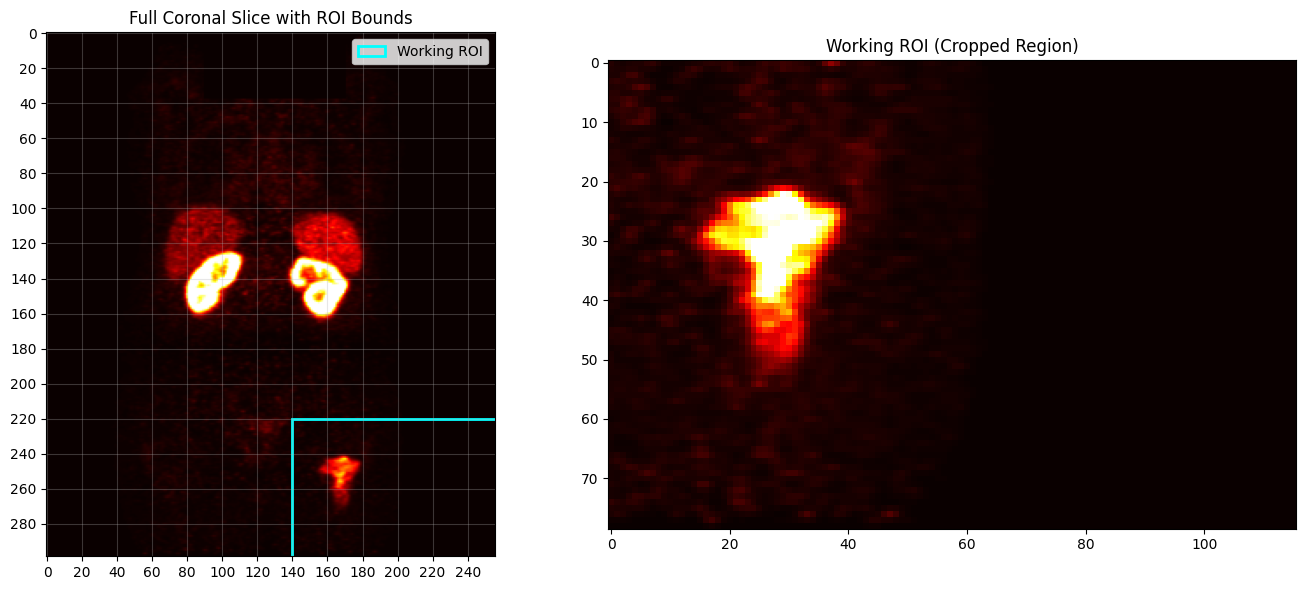

In [96]:
# Extract and display coronal slice
coronal_raw = spect_array[:, CORONAL_SLICE, :]#
coronal_vis = np.fliplr(np.rot90(coronal_raw, 2))# SE ROTAN 180 GRADOS Y SE VOLTEA HORIZONTALMENTE PARA QUE LA IMAGEN CORONAL SE VISUALICE CORRECTAMENTE


# Crop to working region
roi_img = coronal_vis[ROI_CROP[0]:, ROI_CROP[1]:]# se recorta la imagen coronal para obtener la región de interés (ROI) a partir de las coordenadas especificadas en ROI_CROP

print(f" Coronal slice extracted and processed")
print(f"  - Coronal slice index: {CORONAL_SLICE}")
print(f"  - Full coronal shape: {coronal_vis.shape}")
print(f"  - Working ROI shape: {roi_img.shape}")
print(f"  - ROI intensity range: [{roi_img.min():.2f}, {roi_img.max():.2f}]")

# Visualize working ROI
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full coronal image
axes[0].imshow(
    coronal_vis,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(coronal_vis, 99)
)

# Coordinate grid
axes[0].set_xticks(np.arange(0, coronal_vis.shape[1], 20))
axes[0].set_yticks(np.arange(0, coronal_vis.shape[0], 20))
axes[0].grid(True, alpha=0.3)

# ROI rectangle
roi_rect = patches.Rectangle(
    (ROI_CROP[1], ROI_CROP[0]),               # (x, y)
    coronal_vis.shape[1] - ROI_CROP[1],      # width
    coronal_vis.shape[0] - ROI_CROP[0],      # height
    linewidth=2,
    edgecolor="cyan",
    facecolor="none",
    label="Working ROI"
)

axes[0].add_patch(roi_rect)

axes[0].set_title("Full Coronal Slice with ROI Bounds")
axes[0].legend()

# Cropped ROI
axes[1].imshow(
    roi_img,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(roi_img, 99)
)

axes[1].set_title("Working ROI (Cropped Region)")
axes[1].axis("on")

plt.tight_layout()
plt.show()

### ____________________________________________________________________________-

✓ Manual segmentation loaded
  - Segmented voxels (3D): 4828
  - Segmented pixels in ROI: 318


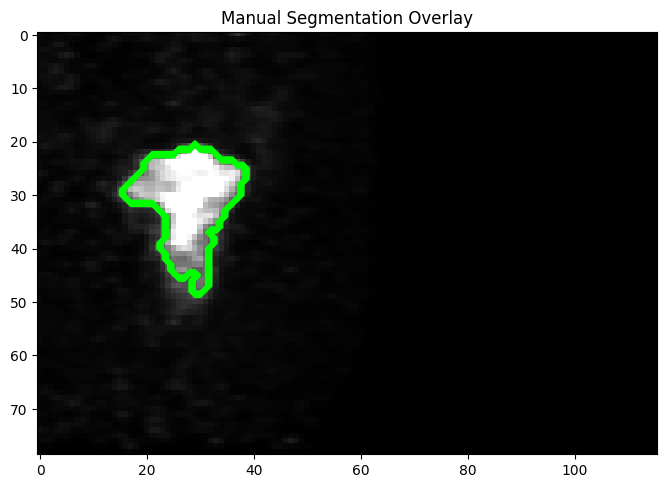

In [97]:
# ==============================================================================
# ! Stage 1.5: Load Manual Segmentation (DICOM SEG)
# ==============================================================================

SEG_PATH = DATA_DIR / "SEGMENTATIONS" / "1-1.dcm"

def load_manual_segmentation(
    seg_path,
    spect_dir,
    spect_array,
    coronal_slice,
    roi_crop
):
    """
    Load DICOM SEG, reconstruct full 3D segmentation volume,
    extract the same coronal plane used by the algorithm,
    and apply identical visualization transforms and ROI crop.
    """

    # Load SEG object
    seg = pydicom.dcmread(str(seg_path))
    seg_array = seg.pixel_array.astype(np.uint8)

    # Build UID -> slice index map from SPECT series
    spect_files = sorted(Path(spect_dir).glob("*.dcm"))

    uid_to_slice = {}

    for idx, f in enumerate(spect_files):

        ds = pydicom.dcmread(
            str(f),
            stop_before_pixels=True
        )

        uid_to_slice[ds.SOPInstanceUID] = idx

    # Determine which SPECT slice corresponds to each SEG frame
    seg_slices = []

    for frame in seg.PerFrameFunctionalGroupsSequence:

        uid = (
            frame.DerivationImageSequence[0]
            .SourceImageSequence[0]
            .ReferencedSOPInstanceUID
        )

        if uid in uid_to_slice:
            seg_slices.append(uid_to_slice[uid])

    # Reconstruct full 3D segmentation volume
    manual_mask_3d = np.zeros_like(
        spect_array,
        dtype=np.uint8
    )

    for frame_idx, spect_idx in enumerate(seg_slices):
        manual_mask_3d[spect_idx] = seg_array[frame_idx]

    # Extract same coronal plane
    manual_coronal_raw = manual_mask_3d[:, coronal_slice, :]

    # Apply same visualization orientation
    manual_coronal_vis = np.flipud(
        np.fliplr(
            np.rot90(manual_coronal_raw, 2)
        )
    )

    # Apply same ROI crop
    manual_mask_roi = manual_coronal_vis[
        roi_crop[0]:,
        roi_crop[1]:
    ]

    return (
        manual_mask_3d,
        manual_coronal_vis,
        manual_mask_roi
    )

# Load manual segmentation
manual_mask_3d, manual_coronal_vis, manual_mask_roi = (
    load_manual_segmentation(
        SEG_PATH,
        SPECT_DIR,
        spect_array,
        CORONAL_SLICE,
        ROI_CROP
    )
)

print("✓ Manual segmentation loaded")
print(f"  - Segmented voxels (3D): {manual_mask_3d.sum()}")
print(f"  - Segmented pixels in ROI: {manual_mask_roi.sum()}")

# Visual verification

plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img, 99)
)

plt.contour(
    manual_mask_roi,
    colors="lime",
    linewidths=2
)

plt.title("Manual Segmentation Overlay")
plt.show()

### _____________________________________________________________________________________________

## Stage 2: Initial Lesion Mask (ROI0)

 Initial mask (ROI0) created
  - Threshold: 65% of max = 12639.98
  - Mask size: 76 voxels


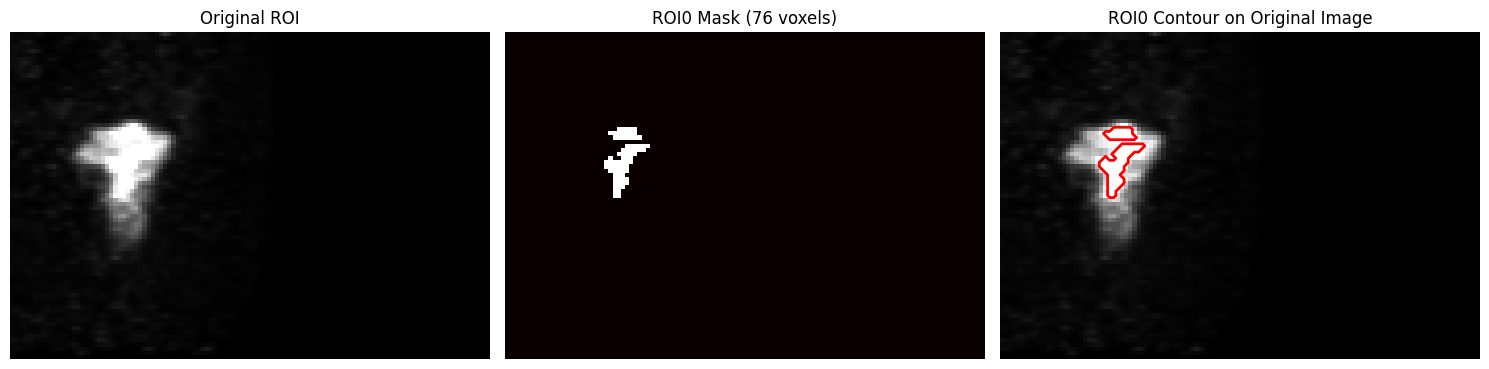

In [98]:
# Create initial lesion mask (ROI0)
threshold = THRESHOLD_PERCENTILE * roi_img.max() 
mask0 = roi_img > threshold # todo voxel con intensidad mayor al umbral se considera parte de la lesión y se marca como True en la máscara binaria mask0

print(f" Initial mask (ROI0) created")
print(f"  - Threshold: {THRESHOLD_PERCENTILE * 100:.0f}% of max = {threshold:.2f}")
print(f"  - Mask size: {mask0.sum()} voxels")

# Visualize initial mask
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].set_title("Original ROI")
axes[0].axis('off')

axes[1].imshow(mask0, cmap="hot")
axes[1].set_title(f"ROI0 Mask ({mask0.sum()} voxels)")
axes[1].axis('off')

axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='r', linewidths=2)
axes[2].set_title("ROI0 Contour on Original Image")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Stage 3: PyRadiomics Setup & Utility Functions

## Initialize custom GLCM helper

The notebook uses PyRadiomics GLCM matrices only as an intermediate step to compute the custom Local Entropy reference and all directional trial values.

In [99]:
# ==============================================================================
# Initialize PyRadiomics settings for custom Local Entropy via GLCM matrices
# ==============================================================================

print("✓ Custom Local Entropy setup ready")
print("  - PyRadiomics GLCM is used only to build directional GLCM matrices")
print(f"  - binWidth       = {GLCM_SETTINGS['binWidth']}")
print(f"  - kernelRadius   = {GLCM_SETTINGS['kernelRadius']}")
print(f"  - distances      = {GLCM_SETTINGS['distances']}")
print(f"  - weightingNorm  = {GLCM_SETTINGS['weightingNorm']}")
print(f"  - normalize      = {GLCM_SETTINGS['normalize']}")
print(f"  - force2D        = {GLCM_SETTINGS['force2D']}")
print(f"  - force2Ddim     = {GLCM_SETTINGS['force2Ddimension']}")
print(f"  - symmetricalGLCM = {GLCM_SETTINGS['symmetricalGLCM']}")

✓ Custom Local Entropy setup ready
  - PyRadiomics GLCM is used only to build directional GLCM matrices
  - binWidth       = 25
  - kernelRadius   = 1
  - distances      = [1]
  - weightingNorm  = None
  - normalize      = False
  - force2D        = True
  - force2Ddim     = 0
  - symmetricalGLCM = True


In [100]:
def reconstruct_voxel_map(result_dict, reference_shape, feature_key):
    """
    result_dict: diccionario de resultados de PyRadiomics que contiene la característica extraída y la bounding box
    reference_shape: la forma de la imagen original
    feature_key: clave de la característica en result_dict (ej. "original_firstorder_M
    
    Tomar el mapa radiomico (que viene en bounding box) y colocarlo de nuevo en 
    la imagen original. ME DA UN ARRAY CON el mapa radiomico voxel-based reubicado en el sistema original de la imagen (80×60), lo que 
    no esta en el bounding box esta llenos de ceros sin filtrar aun con la mascara
    """
    bbox_key = "diagnostics_Mask-original_BoundingBox"  # variable donde PyRadiomics guarda la bounding box
    if bbox_key not in result_dict:  # verifica que la bounding box esté presente en el resultado
        raise ValueError(f"Bounding box not found in result. Available keys: {result_dict.keys()}")  # lanza error si falta
    
    bbox = result_dict[bbox_key]  # extrae la tupla bounding box
    x, y, z, sx, sy, sz = bbox  # desempaqueta las coordenadas y tamaños del bounding box
    
    if feature_key not in result_dict:  # comprueba que la clave de la característica exista en el resultado
        raise ValueError(
            f"Feature key '{feature_key}' not found in result. Available keys: {list(result_dict.keys())}"
        )  # lanza error si la característica no está presente
    feature_img = result_dict[feature_key]  # obtiene la imagen SimpleITK correspondiente a la característica
    median_map = sitk.GetArrayFromImage(feature_img)[0]  # convierte la imagen a numpy y toma la primera (única) z-slice
    
    full_map = np.zeros(reference_shape, dtype=float)  # inicializa el mapa completo con ceros (float)
    
    h, w = median_map.shape  # obtiene alto y ancho del mapa dentro del bounding box
    x0 = x - 1  # convierte la coordenada x de 1-based (PyRadiomics) a 0-based (numpy)
    y0 = y - 1  # convierte la coordenada y de 1-based a 0-based
    
    full_map[
        y0:y0 + h,
        x0:x0 + w
    ] = median_map  # inserta el mapa extraído en la posición correspondiente del mapa completo
    
    return full_map, (x0, y0, h, w)  # devuelve el mapa reconstruido y la información de bounding box ajustada

print("✓ Utility function 'reconstruct_voxel_map' defined")  # confirma que la función ha sido definida


✓ Utility function 'reconstruct_voxel_map' defined


## Stage 4: Fixed Local Entropy Reference (ROI0)

Type of P_glcm: <class 'numpy.ndarray'>
Shape of P_glcm: (1, 63, 63, 4)
Number of dimensions: 4

Direction 0
Shape: (63, 63)
Sum: 0.9999999999999999
Non-zero elements: 94

Direction 1
Shape: (63, 63)
Sum: 1.0
Non-zero elements: 110

Direction 2
Shape: (63, 63)
Sum: 1.0
Non-zero elements: 104

Direction 3
Shape: (63, 63)
Sum: 1.0
Non-zero elements: 115

Are direction 0 and direction 1 identical? False
✓ ROI0 Local Entropy computed
  - ROI0 voxels: 76
  - Directional GLCM matrices: 4
  - ROI0_LE: -4.655901
  - Directional Local Entropy values:
      [1] -4.543295
      [2] -4.700480
      [3] -4.644391
      [4] -4.735440


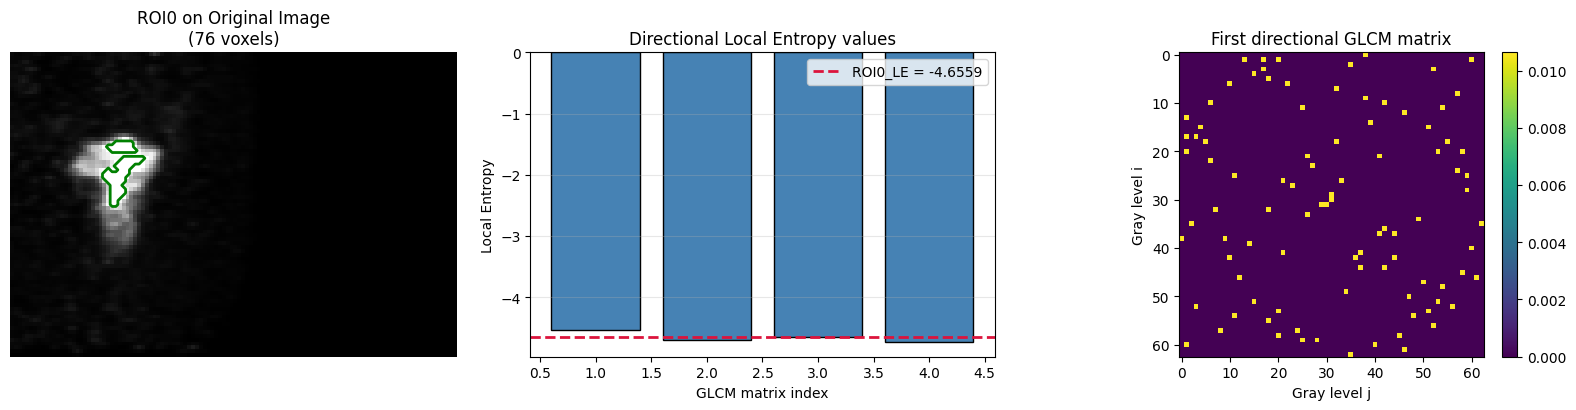

In [101]:
# ==============================================================================
# Extract ROI0 fixed Local Entropy reference and directional GLCM matrices
# ==============================================================================

roi0_entropy_data = _extract_glcm_matrices(roi_img, mask0)
ROI0_LE = roi0_entropy_data["roi_local_entropy"]
ROI0_DIRECTIONAL_LE = roi0_entropy_data["directional_local_entropies"]
ROI0_DIRECTIONAL_GLCM_MATRICES = roi0_entropy_data["directional_glcm_matrices"]
ROI0_GLCM_MATRIX_COUNT = roi0_entropy_data["glcm_matrix_count"]

print(f"✓ ROI0 Local Entropy computed")
print(f"  - ROI0 voxels: {mask0.sum()}")
print(f"  - Directional GLCM matrices: {ROI0_GLCM_MATRIX_COUNT}")
print(f"  - ROI0_LE: {ROI0_LE:.6f}")
print("  - Directional Local Entropy values:")
for idx, value in enumerate(ROI0_DIRECTIONAL_LE, start=1):
    print(f"      [{idx}] {value:.6f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].contour(mask0, colors='g', linewidths=2)
axes[0].set_title(f"ROI0 on Original Image\n({mask0.sum()} voxels)")
axes[0].axis('off')

axes[1].bar(np.arange(1, ROI0_GLCM_MATRIX_COUNT + 1), ROI0_DIRECTIONAL_LE, color='steelblue', edgecolor='k')
axes[1].axhline(ROI0_LE, color='crimson', linestyle='--', linewidth=2, label=f'ROI0_LE = {ROI0_LE:.4f}')
axes[1].set_title("Directional Local Entropy values")
axes[1].set_xlabel("GLCM matrix index")
axes[1].set_ylabel("Local Entropy")
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

first_glcm_matrix = ROI0_DIRECTIONAL_GLCM_MATRICES[0] if ROI0_DIRECTIONAL_GLCM_MATRICES else np.zeros((1, 1), dtype=float)
im = axes[2].imshow(first_glcm_matrix, cmap="viridis")
axes[2].set_title("First directional GLCM matrix")
axes[2].set_xlabel("Gray level j")
axes[2].set_ylabel("Gray level i")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Stage 5: Iterative Directional Region Growing

In [102]:
# Iterative directional region growing with fixed ROI0 Local Entropy reference
roi_final, iteration_history, stopping_reason = run_directional_region_growing(
    mask0,
    ROI0_LE
)
# Preserve the legacy notebook variable name for downstream cells
history = iteration_history
results = iteration_history

print("\n✓ Voxel-wise Local Entropy growing completed!")
print(f"Stopping reason: {stopping_reason}")
print(f"Initial ROI size: {mask0.sum()} voxels")
print(f"Final ROI size: {roi_final.sum()} voxels")

Starting voxel-wise Local Entropy growing (15 iterations max)...

Type of P_glcm: <class 'numpy.ndarray'>
Shape of P_glcm: (1, 64, 64, 4)
Number of dimensions: 4

Direction 0
Shape: (64, 64)
Sum: 0.9999999999999999
Non-zero elements: 96

Direction 1
Shape: (64, 64)
Sum: 0.9999999999999999
Non-zero elements: 112

Direction 2
Shape: (64, 64)
Sum: 1.0
Non-zero elements: 104

Direction 3
Shape: (64, 64)
Sum: 1.0
Non-zero elements: 115

Are direction 0 and direction 1 identical? False
Type of P_glcm: <class 'numpy.ndarray'>
Shape of P_glcm: (1, 64, 64, 4)
Number of dimensions: 4

Direction 0
Shape: (64, 64)
Sum: 0.9999999999999999
Non-zero elements: 96

Direction 1
Shape: (64, 64)
Sum: 1.0
Non-zero elements: 112

Direction 2
Shape: (64, 64)
Sum: 1.0
Non-zero elements: 106

Direction 3
Shape: (64, 64)
Sum: 1.0
Non-zero elements: 115

Are direction 0 and direction 1 identical? False
Type of P_glcm: <class 'numpy.ndarray'>
Shape of P_glcm: (1, 64, 64, 4)
Number of dimensions: 4

Direction 0
Sh

In [107]:
# Comprobación de la evolución del LE de referencia
for record in iteration_history:

    print(
        f"Iteración {record['iteration']}: "
        f"LE usado = {record['reference_le_used']:.6f} | "
        f"LE después = {record['reference_le_after']:.6f}"
    )

Iteración 1: LE usado = -4.655901 | LE después = -5.368609
Iteración 2: LE usado = -5.368609 | LE después = -5.736239
Iteración 3: LE usado = -5.736239 | LE después = -6.003585
Iteración 4: LE usado = -6.003585 | LE después = -6.230186
Iteración 5: LE usado = -6.230186 | LE después = -6.427268
Iteración 6: LE usado = -6.427268 | LE después = -6.599451
Iteración 7: LE usado = -6.599451 | LE después = -6.754187
Iteración 8: LE usado = -6.754187 | LE después = -6.891842
Iteración 9: LE usado = -6.891842 | LE después = -7.010842
Iteración 10: LE usado = -7.010842 | LE después = -7.107491
Iteración 11: LE usado = -7.107491 | LE después = -7.188958
Iteración 12: LE usado = -7.188958 | LE después = -7.257467
Iteración 13: LE usado = -7.257467 | LE después = -7.313834
Iteración 14: LE usado = -7.313834 | LE después = -7.347248
Iteración 15: LE usado = -7.347248 | LE después = -7.376930


## Stage 6: Results & Visualizations

In [103]:
# Results summary table
print("\n" + "="*90)
print("DIRECTIONAL LOCAL ENTROPY REGION GROWING RESULTS")
print("="*90)



DIRECTIONAL LOCAL ENTROPY REGION GROWING RESULTS


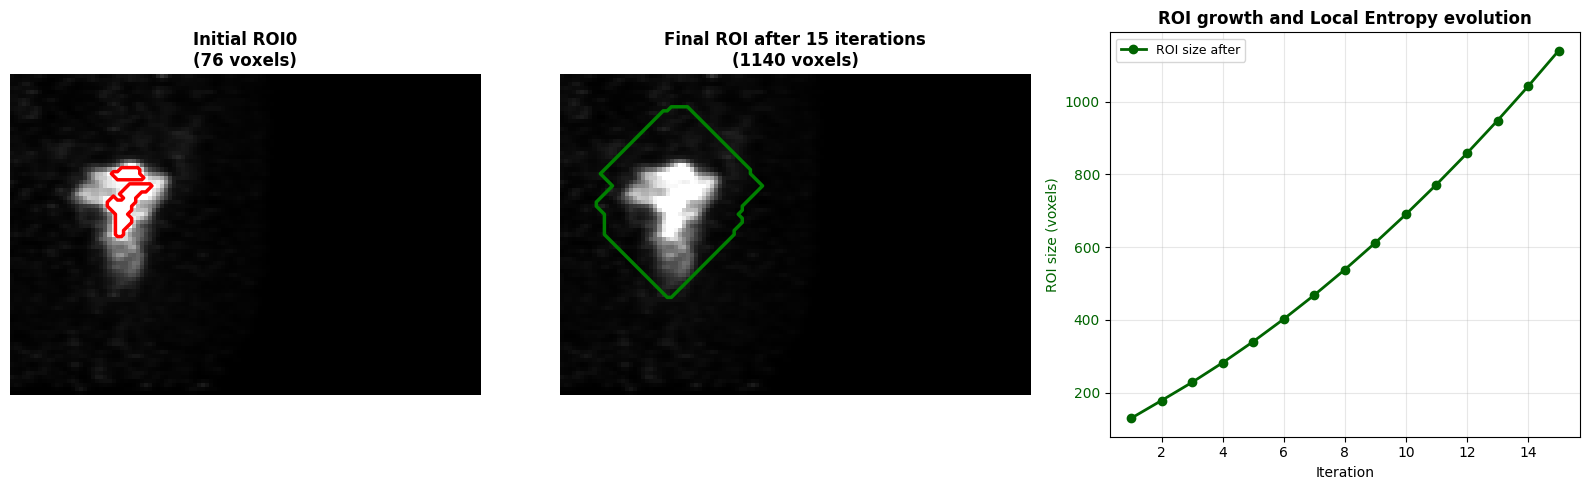

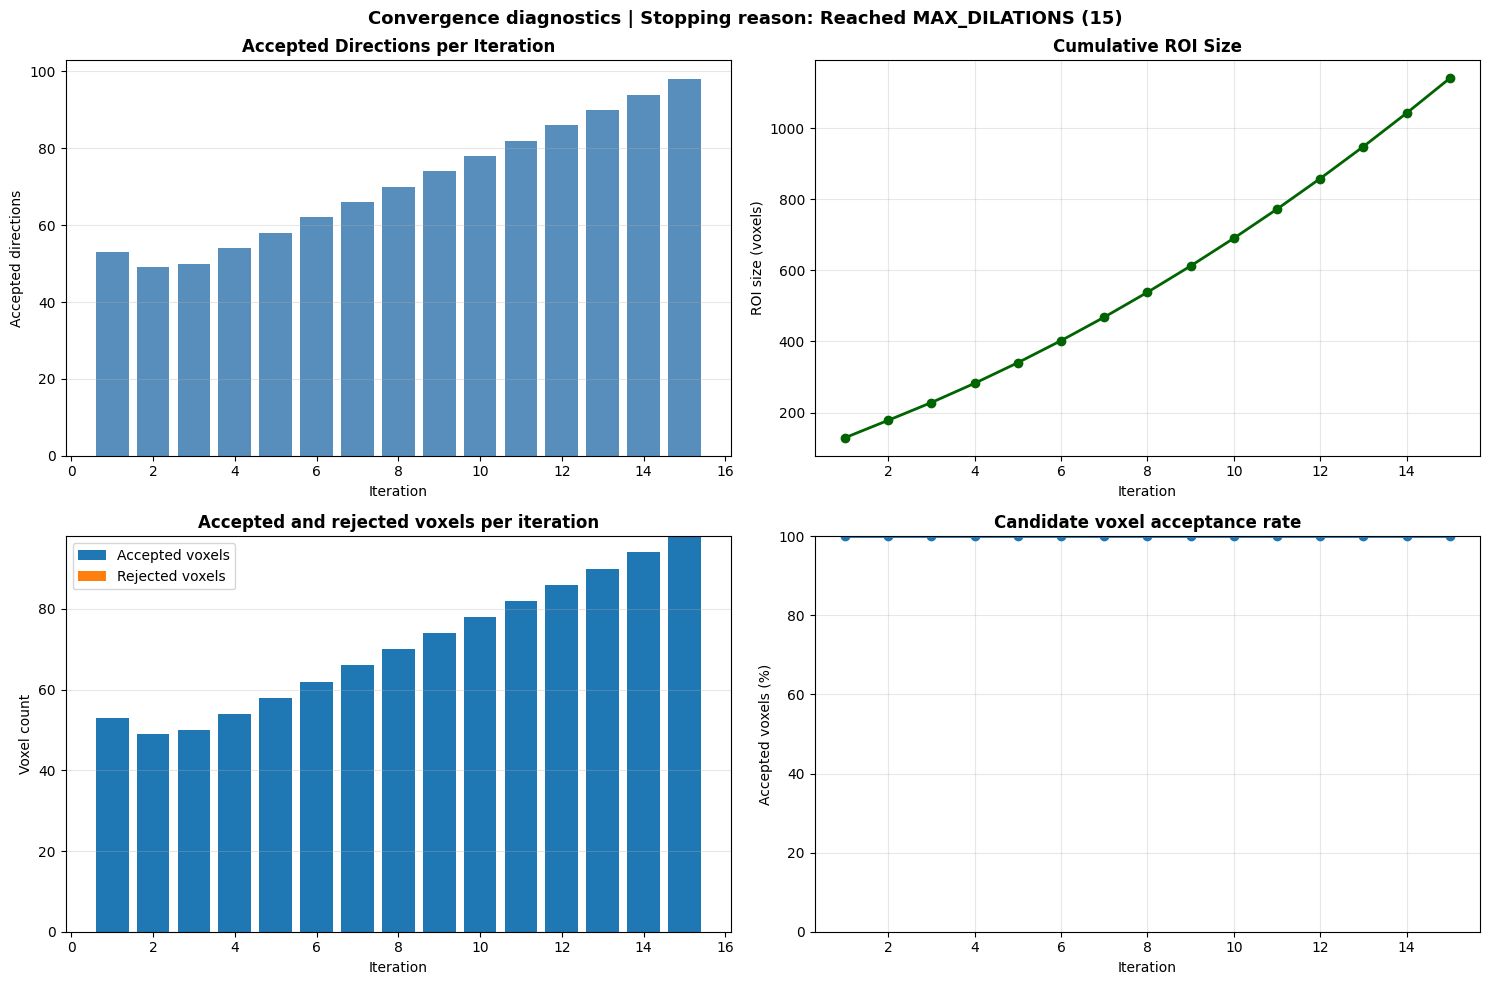

In [104]:
# Visualization: Final ROI evolution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Original image with initial mask
axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].contour(mask0, colors='r', linewidths=2.5)
axes[0].set_title(f"Initial ROI0\n({mask0.sum()} voxels)", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Plot 2: Original image with final ROI
axes[1].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[1].contour(roi_final, colors='g', linewidths=2.5)
axes[1].set_title(f"Final ROI after {MAX_DILATIONS} iterations\n({roi_final.sum()} voxels)", fontsize=12, fontweight='bold')
axes[1].axis('off')

# Plot 3: ROI size and LE evolution
iteration_range = np.array([record["iteration"] for record in iteration_history])
roi_sizes_after = np.array([record["roi_size_after"] for record in iteration_history], dtype=float)
accepted_counts = np.array(
    [record["accepted_voxel_count"] for record in iteration_history],
    dtype=float
)
axes[2].plot(iteration_range, roi_sizes_after, 'o-', linewidth=2, markersize=6, color='darkgreen', label='ROI size after')
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("ROI size (voxels)", color='darkgreen')
axes[2].tick_params(axis='y', labelcolor='darkgreen')
axes[2].grid(alpha=0.3)


axes[2].set_title("ROI growth and Local Entropy evolution", fontsize=12, fontweight='bold')

axes[2].legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

# Convergence diagnostics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].bar(iteration_range, accepted_counts, color='steelblue', alpha=0.9)
axes[0, 0].set_title("Accepted Directions per Iteration", fontweight='bold')
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].set_ylabel("Accepted directions")
axes[0, 0].grid(alpha=0.3, axis='y')

axes[0, 1].plot(iteration_range, roi_sizes_after, 'o-', color='darkgreen', linewidth=2, markersize=6)
axes[0, 1].set_title("Cumulative ROI Size", fontweight='bold')
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("ROI size (voxels)")
axes[0, 1].grid(alpha=0.3)

rejected_counts = np.array(
    [
        record["rejected_voxel_count"]
        for record in iteration_history
    ],
    dtype=float
)

axes[1, 0].bar(
    iteration_range,
    accepted_counts,
    label="Accepted voxels"
)

axes[1, 0].bar(
    iteration_range,
    rejected_counts,
    bottom=accepted_counts,
    label="Rejected voxels"
)

axes[1, 0].set_title(
    "Accepted and rejected voxels per iteration",
    fontweight="bold"
)

axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("Voxel count")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3, axis="y")

acceptance_percentages = np.array(
    [
        (
            record["accepted_voxel_count"]
            / (
                record["accepted_voxel_count"]
                + record["rejected_voxel_count"]
            )
            * 100
        )
        if (
            record["accepted_voxel_count"]
            + record["rejected_voxel_count"]
        ) > 0
        else np.nan
        for record in iteration_history
    ],
    dtype=float
)

axes[1, 1].plot(
    iteration_range,
    acceptance_percentages,
    'o-',
    linewidth=2,
    markersize=6
)

axes[1, 1].set_title(
    "Candidate voxel acceptance rate",
    fontweight='bold'
)

axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Accepted voxels (%)")
axes[1, 1].set_ylim(0, 100)
axes[1, 1].grid(alpha=0.3)

fig.suptitle(f"Convergence diagnostics | Stopping reason: {stopping_reason}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

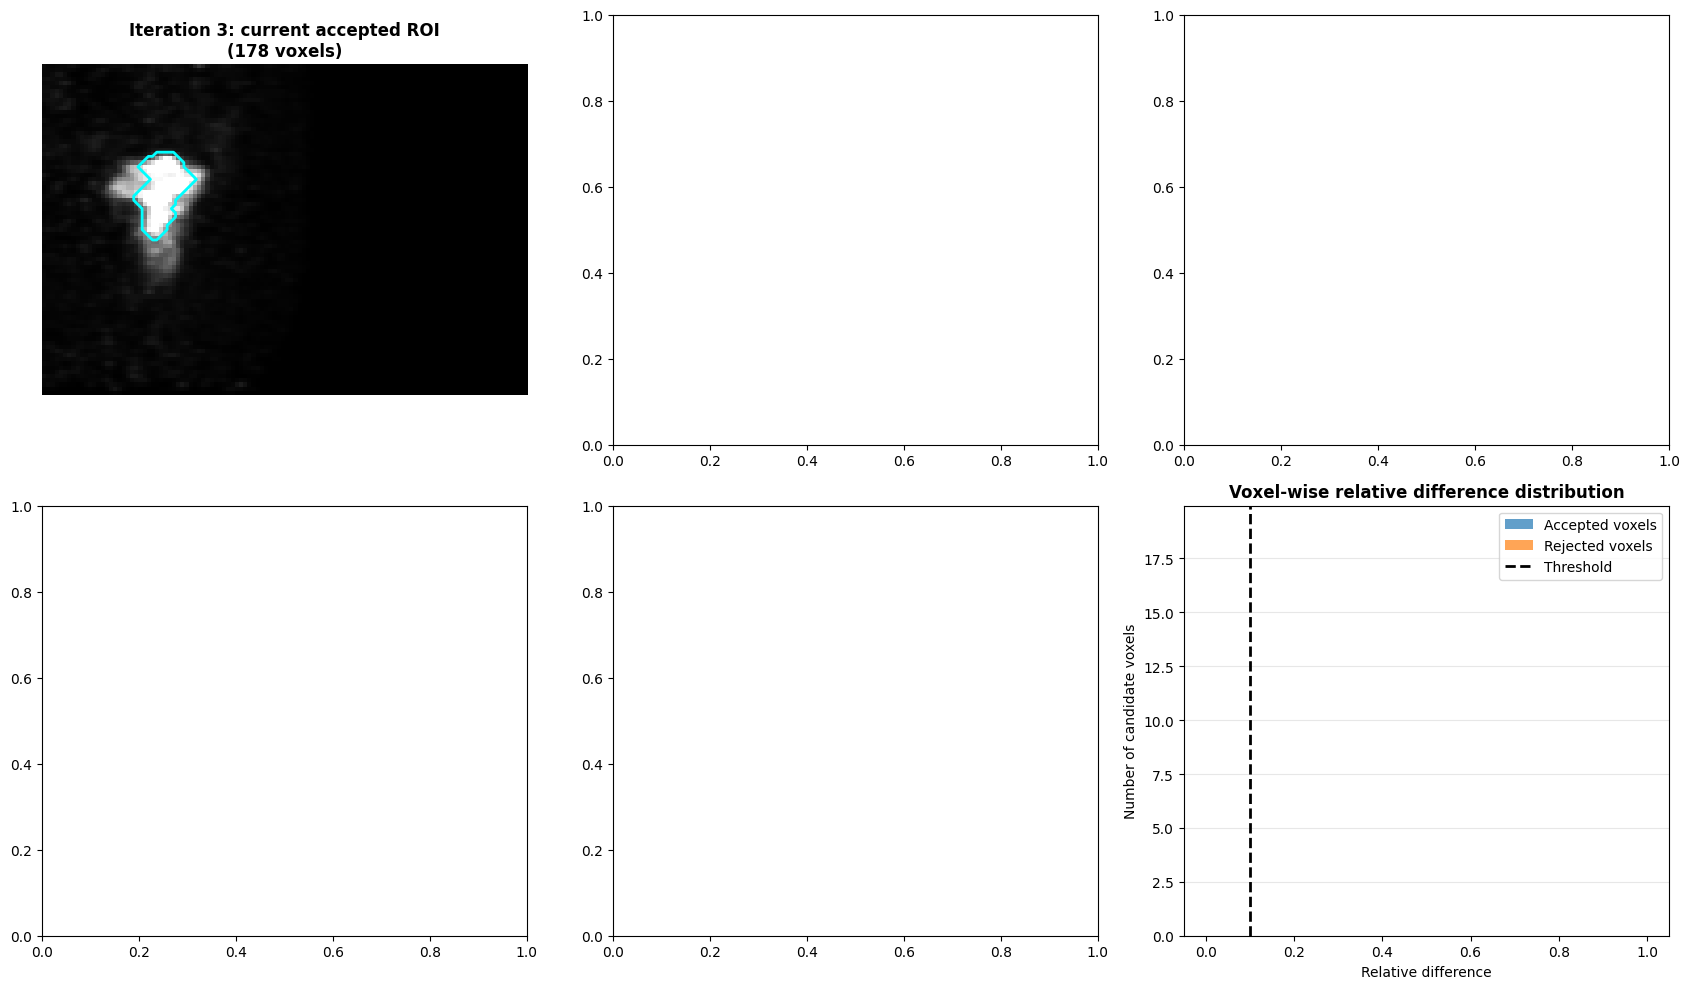


Selected iteration voxel-wise summary:
 Row  Column  Accepted  Trial LE  Relative Difference  New Pixels  Directional GLCM Count
  20      27      True -5.739446             0.000559           1                       4
  20      28      True -5.741051             0.000839           1                       4
  20      29      True -5.741051             0.000839           1                       4
  20      30      True -5.741051             0.000839           1                       4
  20      31      True -5.739411             0.000553           1                       4
  21      25      True -5.739446             0.000559           1                       4
  21      26      True -5.742673             0.001122           1                       4
  21      32      True -5.741033             0.000836           1                       4
  22      24      True -5.741068             0.000842           1                       4
  22      33      True -5.741033             0.000836       

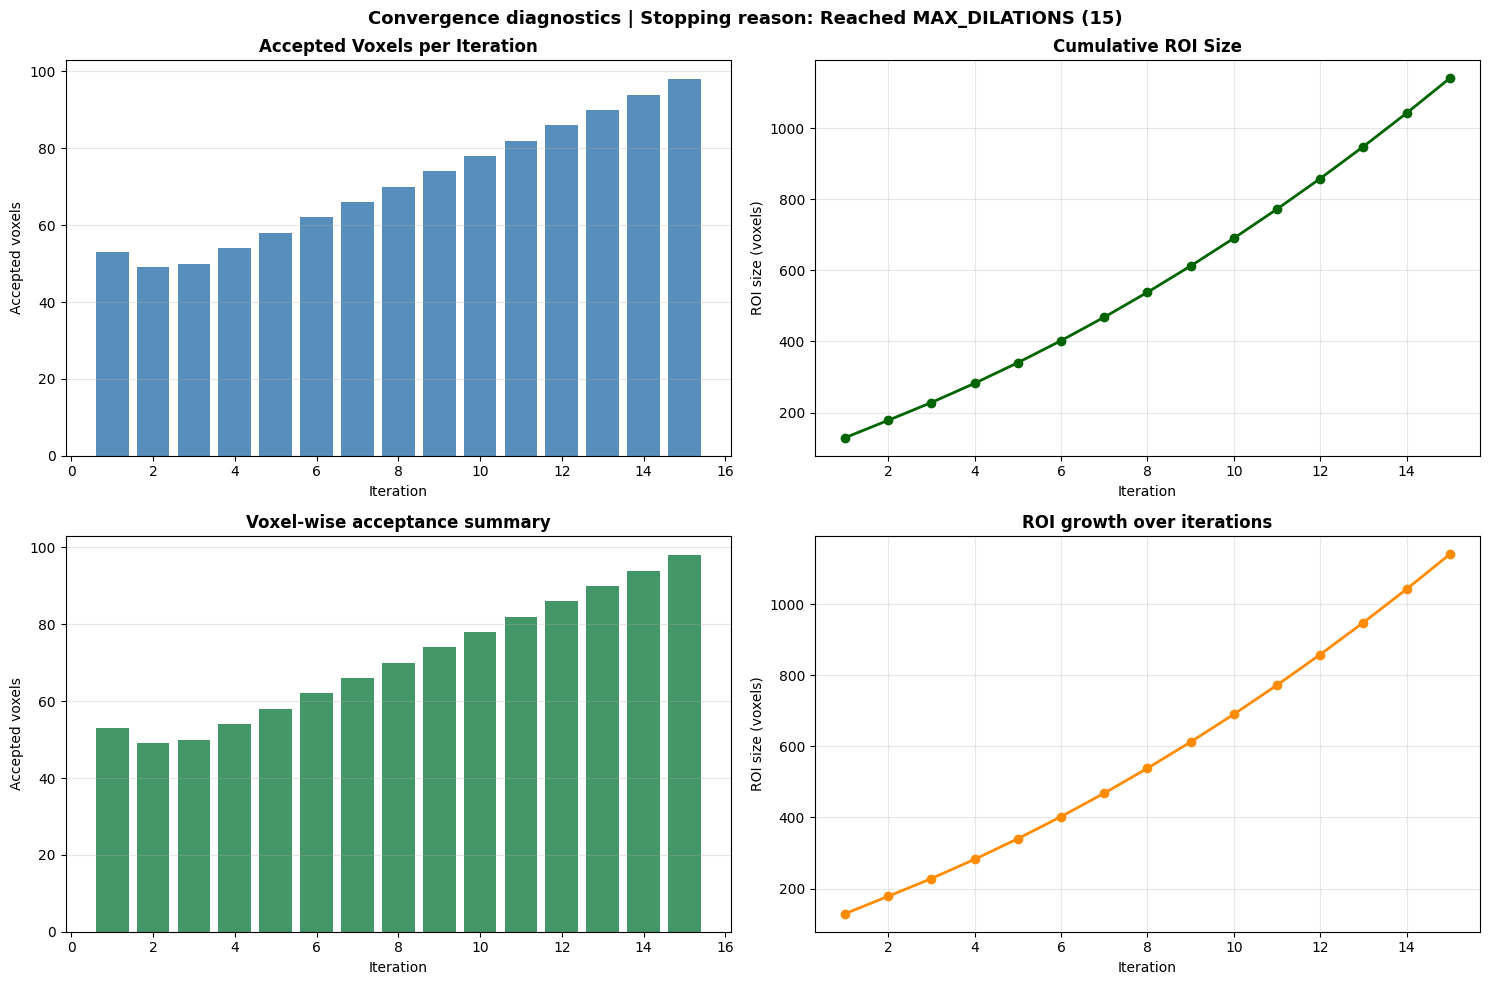

In [105]:
# Detailed visualization of a specific iteration (example: iteration 5)
iter_to_show = min(3, len(iteration_history))  # Show iteration 5, or last if fewer iterations
iteration_data = iteration_history[iter_to_show - 1]
candidate_records = iteration_data["candidate_records"]
direction_labels = {
    "right": "Positive X / Right",
    "left": "Negative X / Left",
    "down": "Positive Y / Down",
    "up": "Negative Y / Up",
}

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Row 1: current ROI and horizontal growth directions
axes[0, 0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0, 0].contour(iteration_data["roi_current"], colors='cyan', linewidths=2)
axes[0, 0].set_title(
    f"Iteration {iter_to_show}: current accepted ROI\n({iteration_data['roi_size_before']} voxels)",
    fontweight='bold'
)
axes[0, 0].axis('off')





# Relative difference for every candidate voxel
relative_differences = np.array(
    [
        record["relative_difference"]
        for record in candidate_records
        if np.isfinite(record["relative_difference"])
    ],
    dtype=float
)

accepted_values = np.array(
    [
        record["relative_difference"]
        for record in candidate_records
        if record["accepted"]
        and np.isfinite(record["relative_difference"])
    ],
    dtype=float
)

rejected_values = np.array(
    [
        record["relative_difference"]
        for record in candidate_records
        if not record["accepted"]
        and np.isfinite(record["relative_difference"])
    ],
    dtype=float
)

axes[1, 2].hist(
    accepted_values,
    bins=20,
    alpha=0.7,
    label="Accepted voxels"
)

axes[1, 2].hist(
    rejected_values,
    bins=20,
    alpha=0.7,
    label="Rejected voxels"
)

axes[1, 2].axvline(
    LE_RELATIVE_THRESHOLD,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Threshold'
)

axes[1, 2].set_title(
    "Voxel-wise relative difference distribution",
    fontweight='bold'
)

axes[1, 2].set_xlabel("Relative difference")
axes[1, 2].set_ylabel("Number of candidate voxels")
axes[1, 2].grid(alpha=0.3, axis='y')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# Voxel-by-voxel summary for the selected iteration
voxel_summary_rows = []

for record in candidate_records:

    voxel_summary_rows.append({

        "Row": record["candidate_position"][0],

        "Column": record["candidate_position"][1],

        "Accepted": record["accepted"],

        "Trial LE": record["trial_le"],

        "Relative Difference": record["relative_difference"],

        "New Pixels": 1,

        "Directional GLCM Count": record["glcm_matrix_count"],

    })

voxel_summary_df = pd.DataFrame(voxel_summary_rows)

print("\nSelected iteration voxel-wise summary:")
print(
    voxel_summary_df.head(20).to_string(index=False)
)
# Convergence diagnostics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

accepted_voxels = np.array(
    [
        record["accepted_voxel_count"]
        for record in iteration_history
    ],
    dtype=float
)

cumulative_size = np.array(
    [
        record["roi_size_after"]
        for record in iteration_history
    ],
    dtype=float
)

metric_threshold = LE_RELATIVE_THRESHOLD

axes[0, 0].bar(
    iteration_range,
    accepted_voxels,
    color='steelblue',
    alpha=0.9
)

axes[0, 0].set_title(
    "Accepted Voxels per Iteration",
    fontweight='bold'
)

axes[0, 0].set_xlabel("Iteration")
axes[0, 0].set_ylabel("Accepted voxels")
axes[0, 0].grid(
    alpha=0.3,
    axis='y'
)


axes[0, 1].plot(
    iteration_range,
    cumulative_size,
    'o-',
    color='darkgreen',
    linewidth=2,
    markersize=6
)

axes[0, 1].set_title(
    "Cumulative ROI Size",
    fontweight='bold'
)

axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("ROI size (voxels)")
axes[0, 1].grid(alpha=0.3)


axes[1, 0].set_title(
    "Voxel-wise acceptance summary",
    fontweight='bold'
)

axes[1, 0].bar(
    iteration_range,
    accepted_voxels,
    color='seagreen',
    alpha=0.9
)

axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("Accepted voxels")
axes[1, 0].grid(
    alpha=0.3,
    axis='y'
)


axes[1, 1].plot(
    iteration_range,
    cumulative_size,
    'o-',
    color='darkorange',
    linewidth=2,
    markersize=6
)

axes[1, 1].set_title(
    "ROI growth over iterations",
    fontweight='bold'
)

axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("ROI size (voxels)")
axes[1, 1].grid(alpha=0.3)


fig.suptitle(
    f"Convergence diagnostics | Stopping reason: {stopping_reason}",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [106]:
vivhil

NameError: name 'vivhil' is not defined

## Stage 7: Comparison with manual segmentation

In [ ]:
# ==============================================================================
# Stage 7.1: Basic Overlap Analysis
# ==============================================================================

manual = manual_mask_roi.astype(bool)
auto = roi_final.astype(bool)

TP = np.logical_and(manual, auto).sum()
FP = np.logical_and(~manual, auto).sum()
FN = np.logical_and(manual, ~auto).sum()
TN = np.logical_and(~manual, ~auto).sum()

print("="*60)
print("OVERLAP ANALYSIS")
print("="*60)

print(f"Manual voxels:     {manual.sum()}")
print(f"Automatic voxels:  {auto.sum()}")

print()
print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"TN: {TN}")

OVERLAP ANALYSIS
Manual voxels:     318
Automatic voxels:  282

TP: 237
FP: 45
FN: 81
TN: 8801


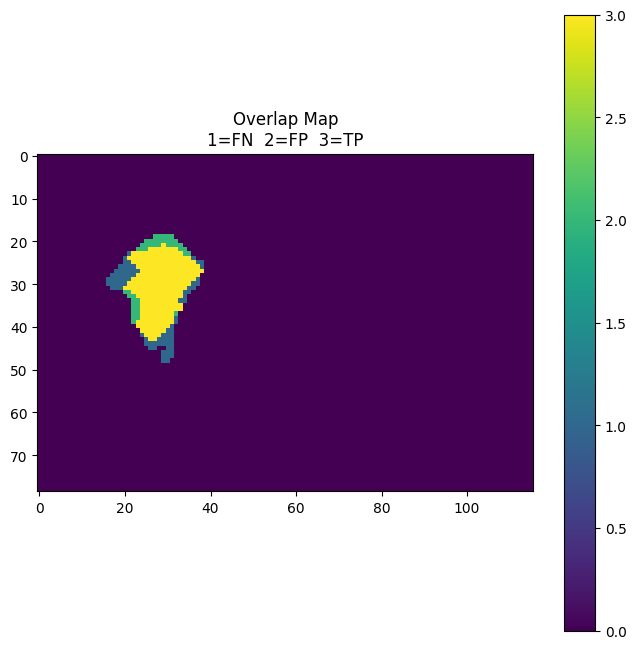

In [ ]:
# ==============================================================================
# Visual overlap map
# ==============================================================================

overlap = np.zeros_like(manual, dtype=np.uint8)

overlap[manual & auto] = 3      # TP
overlap[~manual & auto] = 2     # FP
overlap[manual & ~auto] = 1     # FN

plt.figure(figsize=(8,8))

plt.imshow(overlap)

plt.title(
    "Overlap Map\n"
    "1=FN  2=FP  3=TP"
)

plt.colorbar()
plt.show()

C:\Users\oscar\AppData\Local\Temp\ipykernel_12700\829081298.py:10: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(
C:\Users\oscar\AppData\Local\Temp\ipykernel_12700\829081298.py:17: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(


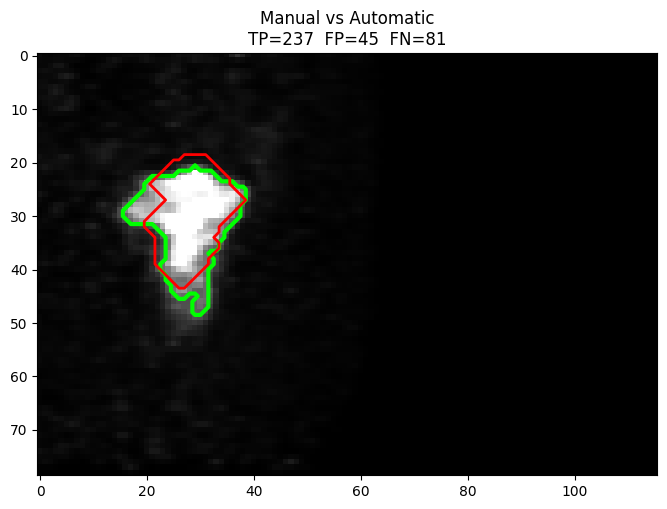

In [ ]:
plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img,99)
)

plt.contour(
    manual,
    colors="lime",
    linewidths=3,
    label="Manual"
)

plt.contour(
    auto,
    colors="red",
    linewidths=2,
    label="Automatic"
)

plt.title(
    f"Manual vs Automatic\n"
    f"TP={TP}  FP={FP}  FN={FN}"
)

plt.show()

In [ ]:

dice = (2 * TP) / (2 * TP + FP + FN)

iou = TP / (TP + FP + FN)

recall = TP / (TP + FN)

precision = TP / (TP + FP)

metrics_df = pd.DataFrame({
    "Metric": [
        "Dice",
        "IoU",
        "Recall",
        "Precision"
    ],
    "Value": [
        dice,
        iou,
        recall,
        precision
    ]
})

print(f"Final Dice coefficient: {dice:.4f}")

metrics_df

Final Dice coefficient: 0.7900


,Metric,Value
0,Dice,0.790000
1,IoU,0.652893
2,Recall,0.745283
3,Precision,0.840426
